In [26]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pyusadel import DifferentialOperators, UsadelProblem, gradient, laplacian

In [27]:
Nx = 801
x = np.linspace(-20, 20, Nx)
dx = x[1] - x[0]

h_x = np.zeros((Nx), dtype=float)
h_y = np.zeros((Nx), dtype=float)
h_z = np.zeros((Nx), dtype=float)

h_x[: Nx // 2] = 0.5
h_x[Nx // 2 :] = 0.0

tau_sf_inv = np.zeros((Nx), dtype=float)
tau_so_inv = np.zeros((Nx), dtype=float)

In [28]:
do = DifferentialOperators()
do.D_x = gradient(Nx, dx, boundary_condition="open")
do.D_y = np.zeros((Nx, Nx), dtype=float)
do.D_z = np.zeros((Nx, Nx), dtype=float)
do.L = laplacian(Nx, dx, boundary_condition="open")
do.dx = dx

D = 1.7655
T = 0.2

up = UsadelProblem(
    Nsites=Nx,
    diff_ops=do,
    h_x=h_x,
    h_y=h_y,
    h_z=h_z,
    tau_sf_inv=tau_sf_inv,
    tau_so_inv=tau_so_inv,
    D=D,
    T=T,
    Gamma=1e-3,
    use_dense=False,
)

up.Delta = np.ones((Nx), dtype=float)
up.Delta[: Nx // 2] = 1.764
up.Delta[Nx // 2:] = 0

In [29]:
h_c0 = up.h_c0
xi_00 = up.xi_00
Delta_00 = up.Delta_00

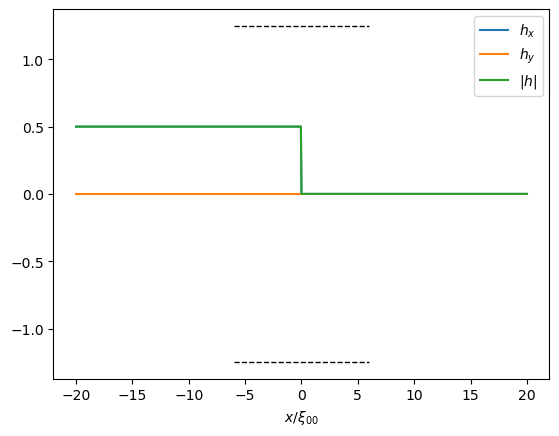

In [30]:
fig, ax = plt.subplots()
ax.hlines([h_c0, -h_c0], -6, 6, colors="k", linestyles="--", linewidth=1)
ax.plot(x / xi_00, h_x, "-", label=r"$h_x$")
ax.plot(x / xi_00, h_y, "-", label=r"$h_y$")
ax.plot(x / xi_00, np.sqrt(h_x**2 + h_y**2), "-", label=r"$|h|$")
ax.set_xlabel(r"$x / \xi_{00}$")
ax.legend()

## Gap equation solver

In [7]:
up.solve_self_consistent(verbose=True)

  1    Max Delta: 1.764    Residual: 2.02e-02    Free energy: -4.40e+02
  2    Max Delta: 1.764    Residual: 1.41e-02    Free energy: -4.56e+02
  3    Max Delta: 1.763    Residual: 1.31e-02    Free energy: -4.66e+02
  4    Max Delta: 1.763    Residual: 1.34e-02    Free energy: -4.76e+02
  5    Max Delta: 1.763    Residual: 1.43e-02    Free energy: -4.85e+02
  6    Max Delta: 1.762    Residual: 1.55e-02    Free energy: -4.96e+02
  7    Max Delta: 1.762    Residual: 1.67e-02    Free energy: -5.07e+02
  8    Max Delta: 1.762    Residual: 1.80e-02    Free energy: -5.19e+02
  9    Max Delta: 1.762    Residual: 1.91e-02    Free energy: -5.32e+02
 10    Max Delta: 1.762    Residual: 2.02e-02    Free energy: -5.46e+02
 11    Max Delta: 1.762    Residual: 2.12e-02    Free energy: -5.61e+02
 12    Max Delta: 1.762    Residual: 2.21e-02    Free energy: -5.76e+02
 13    Max Delta: 1.762    Residual: 2.29e-02    Free energy: -5.93e+02
 14    Max Delta: 1.762    Residual: 2.37e-02    Free energy: -6

In [31]:
cc_idx = np.argsort(np.abs(np.abs(h_x) - h_c0))

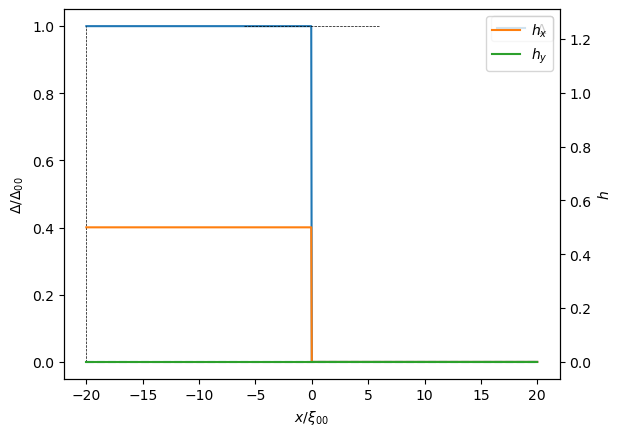

In [32]:
fig, ax = plt.subplots()
ax.plot(x / xi_00, up.Delta / Delta_00, "-C0", label=r"$\Delta$")
ax.set_ylabel(r"$\Delta / \Delta_{00}$")
ax.vlines(x[cc_idx[0]] / xi_00, 0, 1, colors="k", linestyles="--", linewidth=0.5)
# ax.vlines([x[cc_idx[1]]/xi_00], 0, 1, colors="-k", linestyles="--", linewidth=1)
ax.plot(
    x / xi_00,
    up.Delta[Nx // 2 + 10] / Delta_00
    + (np.diff(up.Delta / Delta_00) / (x[1] - x[0]))[Nx // 2 + 10]
    * (x - x[Nx // 2 + 10]),
    "C0--",
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel(r"$x/\xi_{00}$")

ax2 = ax.twinx()
ax2.hlines([+h_c0], -6, 6, colors="k", linestyles="--", linewidth=0.5)
# ax2.hlines([-h_c], -6, 6, colors="k", linestyles="--", linewidth=1)

ax2.plot(x / xi_00, h_x, "-C1", label=r"$h_x$")
ax2.plot(x / xi_00, h_y, "-C2", label=r"$h_y$")
ax2.set_ylabel(r"$h$")

ax.legend()
ax2.legend()

## Spectrum solver

In [10]:
up.Gamma = 1e-3

up.set_real_omega_ax(-3, 3, 201)
up.solve_spectral(
    gamma=0.5, tol=1e-6, max_iter=1000, print_exit_status=True,
)

omega=3.00 : converged.
omega=2.97 : converged.
omega=2.94 : converged.
omega=2.91 : converged.
omega=2.88 : converged.
omega=2.85 : converged.
omega=2.82 : converged.
omega=2.79 : converged.
omega=2.76 : converged.
omega=2.73 : converged.
omega=2.70 : converged.
omega=2.67 : converged.
omega=2.64 : converged.
omega=2.61 : converged.
omega=2.58 : converged.
omega=2.55 : converged.
omega=2.52 : converged.
omega=2.49 : converged.
omega=2.46 : converged.
omega=2.43 : converged.
omega=2.40 : converged.
omega=2.37 : converged.
omega=2.34 : converged.
omega=2.31 : converged.
omega=2.28 : converged.
omega=2.25 : converged.
omega=2.22 : converged.
omega=2.19 : converged.
omega=2.16 : converged.
omega=2.13 : converged.
omega=2.10 : converged.
omega=2.07 : converged.
omega=2.04 : converged.
omega=2.01 : converged.
omega=1.98 : converged.
omega=1.95 : converged.
omega=1.92 : converged.
omega=1.89 : converged.
omega=1.86 : converged.
omega=1.83 : converged.
omega=1.80 : converged.
omega=1.77 : con

In [11]:
omega_ax = up.get_omega_ax_r()
DOS = up.get_ldos()
DOSu, DOSd = up.get_spin_resolved_ldos("x")

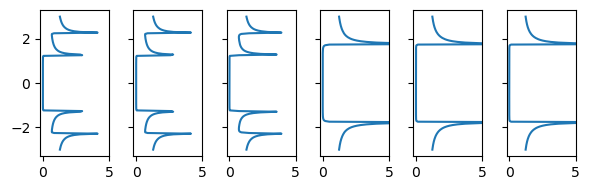

In [12]:
fig, ax = plt.subplots(ncols=6, figsize=(6, 2), sharey=True)

ax[0].plot(
    DOS[:, Nx // 5 * 0 + 10],
    omega_ax,
)
ax[1].plot(
    DOS[:, Nx // 5 * 1],
    omega_ax,
)
ax[2].plot(
    DOS[:, Nx // 5 * 2],
    omega_ax,
)
ax[3].plot(
    DOS[:, Nx // 5 * 3],
    omega_ax,
)

ax[4].plot(
    DOS[:, Nx // 5 * 4],
    omega_ax,
)

ax[5].plot(
    DOS[:, -1],
    omega_ax,
)

for sax in ax:
    sax.set_xlim(-0.2, 5)


fig.tight_layout()

Text(0.5, 1.0, 'LDOS')

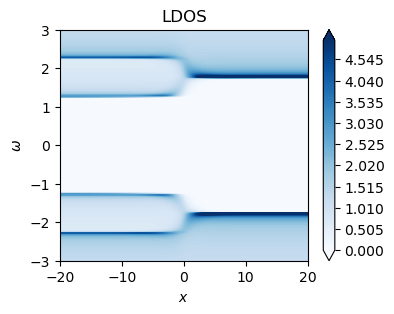

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))

im = ax.contourf(
    x, omega_ax, DOS, extend="both", levels=np.linspace(0, 5, 100), cmap="Blues"
)
fig.colorbar(im)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\omega$")
ax.set_title("LDOS")


## KL boundary conditions

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from pyusadel.findiff import gradient, laplacian, DifferentialOperators
from pyusadel.usadel_oop import UsadelProblem
from pyusadel.utils import thermal_broadening

# ------------------------------------------------------
# Geometry (1D multilayer)
# ------------------------------------------------------
Nx = 100              # number of points across the S film
Lx = 10            # thickness in meters (arbitrary)
dx = Lx / Nx

do = DifferentialOperators()
do.D_x = gradient(Nx, dx, boundary_condition="open")
do.D_y = np.zeros((Nx, Nx))
do.D_z = np.zeros((Nx, Nx))
do.L   = laplacian(Nx, dx, boundary_condition="open")
do.dx  = dx

# ------------------------------------------------------
# Superconductor parameters
# ------------------------------------------------------
Delta0 = 1.764       # gap (eV) ~180 µeV for Al
D = 1.7655
T = 0.2
Gamma = 5e-4          # Dynes parameter (small)
h_x = np.zeros(Nx)
h_y = np.zeros(Nx)
h_z = np.zeros(Nx)

# ------------------------------------------------------
# KL Boundary Condition (N│I│S)
# ------------------------------------------------------
# γ_B = 0 → transparent
# γ_B → +∞ → tunneling limit
gammaB_left = 1    # moderate barrier
gammaB_right = None    # free S at right edge

# ------------------------------------------------------
# Build the Usadel problem
# ------------------------------------------------------
up = UsadelProblem(
    Nsites=Nx,
    diff_ops=do,
    h_x=h_x,
    h_y=h_y,
    h_z=h_z,
    tau_sf_inv=np.zeros(Nx),
    tau_so_inv=np.zeros(Nx),
    D=D,
    T=T,
    Gamma=Gamma,
    kl_left_gammaB=gammaB_left,
    kl_right_gammaB=gammaB_right,
    use_dense=False,
)

# Uniform gap
up.Delta = Delta0 * np.ones(Nx)

# ------------------------------------------------------
# Solve real-frequency Usadel
# ------------------------------------------------------
e_min, e_max = -3, 3 # ±600 µeV energy window
Ne = 600

up.set_real_omega_ax(e_min, e_max, Ne)
energies = up.get_omega_ax_r()

print("Solving Usadel...")
up.solve_spectral(tol=1e-6, max_iter=2000)

Solving Usadel...


/home/skdys/apps/miniconda3/envs/qenv313/lib/python3.13/site-packages/scipy/sparse/_lil.py:272: ComplexWarning: Casting complex values to real discards the imaginary part
  x = self.dtype.type(x)


In [45]:

# LDOS at the interface (x=0)
ldos = up.get_ldos()

# # Thermal broadening (tunneling conductance)
dIdV = thermal_broadening(energies, ldos, T=T)

# # ------------------------------------------------------
# # Plot
# # ------------------------------------------------------
# plt.figure(figsize=(6,4))
# plt.plot(energies*1e6, ldos, label="LDOS (interface)")
# plt.plot(energies*1e6, dIdV, label="dI/dV (thermal broadened)", lw=2)
# plt.xlabel("Energy (µeV)")
# plt.ylabel("Normalized DOS")
# plt.legend()
# plt.title("N│I│S Tunneling – KL Boundary, γB = %.1f" % gammaB_left)
# plt.grid(True)
# plt.show()


ValueError: x and y arrays must be equal in length along interpolation axis.

Text(0.5, 1.0, 'LDOS')

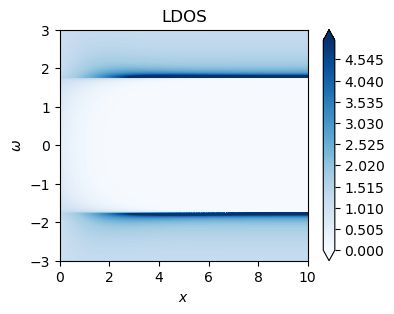

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))

im = ax.contourf(
    np.linspace(0, Lx, Nx), energies, ldos, extend="both", levels=np.linspace(0, 5, 100), cmap="Blues"
)
fig.colorbar(im)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\omega$")
ax.set_title("LDOS")


Text(0, 0.5, 'LDOS at different x')

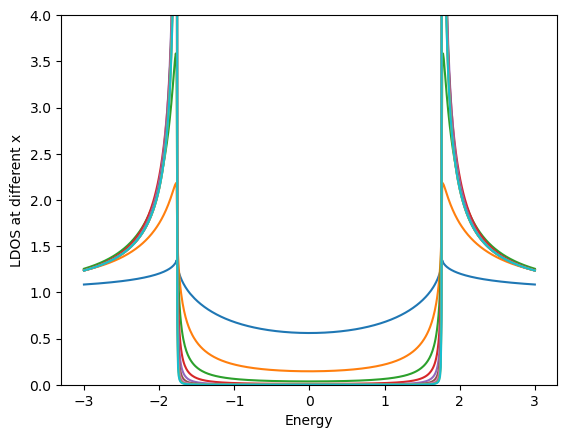

In [44]:
plt.plot(energies, ldos[:, ::10])
plt.ylim(0, 4)
plt.xlabel("Energy")
plt.ylabel("LDOS at different x")


In [ ]:
def thermal_broadening(e_ax: np.ndarray, y: np.ndarray, T: float) -> np.ndarray:
    """
    Computes the thermal broadening of a given spectrum at a given temperature.

    Parameters:
    -----------
    e_ax : np.ndarray
        Array of energy axis values.
    y : np.ndarray
        Array of corresponding values.
    T : float
        Temperature at which to compute the thermal broadening.

    Returns:
    --------
    tb : np.ndarray
        Array of thermal broadening values.

    Raises:
    -------
    AssertionError:
        If the temperature is too low.
    """
    
        return tb



In [11]:
import numpy as np
from scipy.interpolate import interp1d

e_ax = np.linspace(-3, 3, 600)
y = np.exp(-e_ax**2)
T = 0.2


y_f = interp1d(e_ax, y, bounds_error=False, fill_value="extrapolate")

def integrand(x: np.ndarray, e: float, T: float) -> np.ndarray:
    return y_f(e - x * T) / (2 * (1 + np.cosh(x)))

tb: np.ndarray = np.zeros(e_ax.shape, dtype=float)

for i, e in enumerate(e_ax):
    x = np.linspace(e_ax.min() / T, e_ax.max() / T, 4001)
    dx = x[1] - x[0]
    tb[i] = np.sum(integrand(x, e, T)) * dx


In [12]:
tb.dtype

dtype('float64')

In [13]:
np.sum(integrand(x, e, T)) * dx

np.float64(0.0008537488814672906)